In [2]:
# Install YOLOv8
!pip install ultralytics==8.2.103 -q
!pip install roboflow
from IPython import display
display.clear_output()

# Import necessary libraries
from ultralytics import YOLO
from roboflow import Roboflow
import os
from IPython.display import display, Image
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
rf = Roboflow(api_key="2AfHHkSFdde5jaiDkvLq")
project = rf.workspace("ricedisease-zwll3").project("rice_leaf_w_rando")
version = project.version(3)
dataset = version.download("yolov8")

# Set dataset paths
dataset_path = dataset.location  # Path to the dataset downloaded from Roboflow
data_yaml_path = os.path.join(dataset_path, "data.yaml")  # Path to the data.yaml file

# Check the dataset
print(f"Dataset downloaded to: {dataset_path}")
print(f"data.yaml path: {data_yaml_path}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Rice_Leaf_w_Rando-3 in yolov8:: 100%|██████████| 45068/45068 [00:04<00:00, 9342.35it/s] 


Dataset downloaded to: /content/Rice_Leaf_w_Rando-3
data.yaml path: /content/Rice_Leaf_w_Rando-3/data.yaml


In [11]:
# Load a pretrained YOLOv8 model (e.g., YOLOv8n)
model = YOLO("yolov8n.pt")  # Choose a pretrained YOLOv8 model variant

# Train the model
results = model.train(
    data=data_yaml_path,  # Use the variable, not the string "dataset_yaml_path"
    epochs=50,             # Number of training epochs
    imgsz=640,             # Image size (default: 640x640)
    batch=16,              # Batch size
    workers=4,             # Number of workers for data loading
    patience=5,            # Early stopping patience
    optimizer="Adam",     # Optimizer (default: SGD, alternatives: Adam, AdamW)
    plots=True,            # Plot training progress
    val=True,              # Perform validation during training
    device=0               # Specify device (default: auto-detect GPU, use 'cpu' for CPU-only)
)

New https://pypi.org/project/ultralytics/8.3.62 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/Rice_Leaf_w_Rando-3/data.yaml, epochs=50, time=None, patience=5, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=4, project=None, name=train7, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fals

train: Scanning /content/Rice_Leaf_w_Rando-3/train/labels.cache... 19899 images, 3 backgrounds, 7 corrupt: 100%|██████████| 19899/19899 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Healthy_rice_leaf-8-_jpg.rf.0bfc1578f73d5b23355802e242ea9265.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [       1.16]
train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Healthy_rice_leaf-8-_jpg.rf.16412e8a553b2c1c43e081a50907bef7.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0772]
train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Rice_blast-80-_jpg.rf.34c4c42b9ebe2e01d6bf3ee940a0e6c5.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.6836      3.0545]
train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Tungro_virus-14-_jpg.rf.314afc49c6ccb4245c705d225185ca21.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.7957      4.4212      1.3165      8.8423]
train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Tungro_virus-22-_jpg.rf.c6e1fa4dd0621d02c7b9e8

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 3391, len(boxes) = 19891. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/Rice_Leaf_w_Rando-3/valid/labels.cache... 1758 images, 1 backgrounds, 0 corrupt: 100%|██████████| 1758/1758 [00:00<?, ?it/s]

...


24 epochs completed in 0.845 hours.
Optimizer stripped from runs/detect/train7/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train7/weights/best.pt, 6.2MB

Validating runs/detect/train7/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 168 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 55/55 [00:07<00:00,  7.00it/s]


                   all       1758       1757       0.97      0.974      0.993      0.983
              Non-Rice       1434       1434      0.987      0.992      0.995      0.991
             Rice-Leaf        323        323      0.954      0.957       0.99      0.975
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/train7


lr/pg0,█▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▁▅███▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃
lr/pg2,▁▅███▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃
metrics/mAP50(B),▃▁▇▇▇███████████████████
metrics/mAP50-95(B),▂▁▇▇▇▇▇▇█▇██▇▇██████████
metrics/precision(B),▄▁▄▆▆▇▇▇█▇▇███▇█████████
metrics/recall(B),▁▁▃▆▅▇▇▆█▇▇▇▇████▇██▇███
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁


RuntimeError: Parent directory /content/Rice_Leaf_w_Rando-3/runs/detect does not exist.

In [12]:
# Save the trained model
model.save("runs/detect/best_model.pt")

In [13]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

# Load the trained model
model = YOLO("runs/detect/train7/weights/best.pt")  # Load the best model from training

# Evaluate on train split
train_results = model.val(data=data_yaml_path, split="train")
print("Train Metrics:", train_results)

# Evaluate on validation split
val_results = model.val(data=data_yaml_path, split="val")
print("Validation Metrics:", val_results)

# Evaluate on test split
test_results = model.val(data=data_yaml_path, split="test")
print("Test Metrics:", test_results)

Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 168 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/Rice_Leaf_w_Rando-3/train/labels.cache... 19899 images, 3 backgrounds, 7 corrupt: 100%|██████████| 19899/19899 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Healthy_rice_leaf-8-_jpg.rf.0bfc1578f73d5b23355802e242ea9265.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [       1.16]
train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Healthy_rice_leaf-8-_jpg.rf.16412e8a553b2c1c43e081a50907bef7.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0772]
train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Rice_blast-80-_jpg.rf.34c4c42b9ebe2e01d6bf3ee940a0e6c5.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.6836      3.0545]
train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Tungro_virus-14-_jpg.rf.314afc49c6ccb4245c705d225185ca21.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.7957      4.4212      1.3165      8.8423]
train: WARNING ⚠️ /content/Rice_Leaf_w_Rando-3/train/images/Tungro_virus-22-_jpg.rf.c6e1fa4dd0621d02c7b9e8


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1244/1244 [01:42<00:00, 12.17it/s]


                   all      19892      19891      0.987      0.985      0.994      0.991
              Non-Rice      16008      16008      0.992      0.997      0.995      0.994
             Rice-Leaf       3881       3883      0.982      0.972      0.994      0.988
Speed: 0.2ms preprocess, 1.7ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val
Train Metrics: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b1be8fc4c90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0

...

                   all       1758       1757       0.97      0.974      0.993      0.983
              Non-Rice       1434       1434      0.987      0.992      0.995      0.991
             Rice-Leaf        323        323      0.954      0.957       0.99      0.975
Speed: 0.2ms preprocess, 1.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/val2
Validation Metrics: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b1af819c310>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018

val: Scanning /content/Rice_Leaf_w_Rando-3/test/labels... 871 images, 0 backgrounds, 0 corrupt: 100%|██████████| 871/871 [00:00<00:00, 1351.88it/s]

val: New cache created: /content/Rice_Leaf_w_Rando-3/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 142, len(boxes) = 871. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 55/55 [00:05<00:00,  9.61it/s]


                   all        871        871      0.993      0.986      0.994      0.988
              Non-Rice        698        698      0.994          1      0.995      0.993
             Rice-Leaf        173        173      0.992      0.971      0.994      0.982
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val3
Test Metrics: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b1af8d305d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0

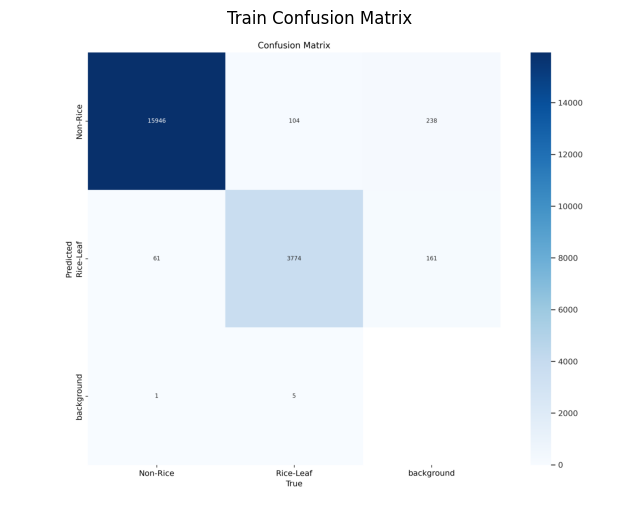

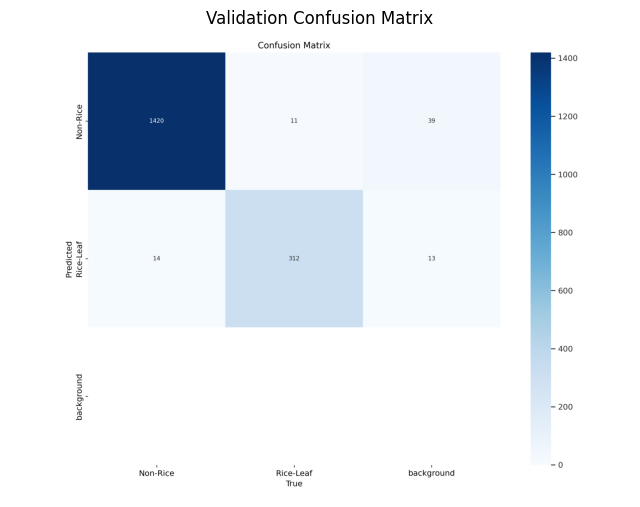

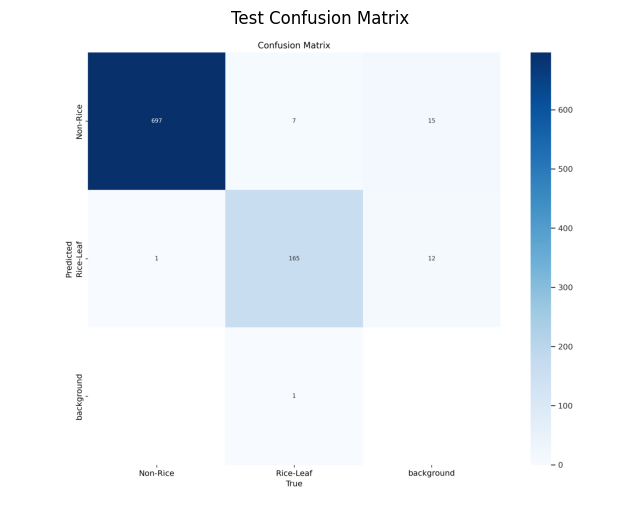

In [18]:
# Function to display confusion matrices
def display_confusion_matrix(results_dir, split):
    conf_matrix_path = os.path.join(results_dir, "confusion_matrix.png")
    if os.path.exists(conf_matrix_path):
        img = plt.imread(conf_matrix_path)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{split.capitalize()} Confusion Matrix")
        plt.show()
    else:
        print(f"No confusion matrix found for {split} split.")

# Paths to results directories
train_dir = "runs/detect/val/"  # Replace trainX with the actual folder for train evaluation
val_dir = "runs/detect/val2/"      # Replace valX with the actual folder for validation evaluation
test_dir = "runs/detect/val3/"    # Replace testX with the actual folder for test evaluation

# Display confusion matrices
display_confusion_matrix(train_dir, "train")
display_confusion_matrix(val_dir, "validation")
display_confusion_matrix(test_dir, "test")